<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 4 – Bot QA con LSTM (Encoder–Decoder)


### Objetivo
Utilizar datos del challenge **ConvAI2** para construir un **bot de preguntas y respuestas** (QA) basado en un modelo **encoder–decoder con LSTM**, siguiendo el esquema visto en clase.

Dataset: http://convai.io/data/


In [62]:
!pip install --quiet gdown

In [63]:
import os
import re
import json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

### 1 – Descarga y carga del dataset

In [64]:
import gdown

if not os.path.exists('data_volunteers.json'):
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN'
    gdown.download(url, 'data_volunteers.json', quiet=False)
else:
    print('Dataset ya descargado')

Dataset ya descargado


In [65]:
with open('data_volunteers.json') as f:
    data = json.load(f)

data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

### 2 – Preprocesamiento
Se generan pares **pregunta → respuesta**, agregando tokens `<sos>` y `<eos>`.

In [66]:
def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

input_sentences = []
output_sentences = []
output_sentences_inputs = []

MAX_LEN = 60 # Se comenzó con 30, pero el modelo no daba buenos resultados y se aumentó a 60

for conv in data:
    dialog = conv['dialog']
    for i in range(len(dialog) - 1):
        q = clean_text(dialog[i]['text'])
        a = clean_text(dialog[i + 1]['text'])
        if len(q) <= MAX_LEN and len(a) <= MAX_LEN:
            input_sentences.append(q)
            output_sentences.append(a + ' <eos>')
            output_sentences_inputs.append('<sos> ' + a)

print('Cantidad de pares QA:', len(input_sentences))

Cantidad de pares QA: 12201


Veamos algunos ejemplos de los datos:

In [84]:
for i in range(5):
    print(f"Input: {input_sentences[i]}")
    print(f"Output: {output_sentences[i]}")
    print("---")

Input: hello 
Output: hi how are you  <eos>
---
Input: hi how are you 
Output: not bad and you  <eos>
---
Input: wowowowow congratulations is she pretty 
Output: she s pretty cute she invited me to dinner tonight  <eos>
---
Input: she s pretty cute she invited me to dinner tonight 
Output: cool have a good time you both and what is your hobby  <eos>
---
Input: cool have a good time you both and what is your hobby 
Output: i love music i love taylor swift  <eos>
---


### Tokenización

In [68]:
MAX_VOCAB = 8000

tokenizer_in = Tokenizer(num_words=MAX_VOCAB)
tokenizer_in.fit_on_texts(input_sentences)
seq_in = tokenizer_in.texts_to_sequences(input_sentences)

word2idx_inputs = tokenizer_in.word_index

tokenizer_out = Tokenizer(num_words=MAX_VOCAB, filters='')
tokenizer_out.fit_on_texts(['<sos>', '<eos>'] + output_sentences)
seq_out = tokenizer_out.texts_to_sequences(output_sentences)
seq_out_in = tokenizer_out.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = tokenizer_out.word_index

max_len_in = max(len(s) for s in seq_in)
max_len_out = max(len(s) for s in seq_out)

encoder_input = pad_sequences(seq_in, maxlen=max_len_in)
decoder_input = pad_sequences(seq_out_in, maxlen=max_len_out, padding='post')
decoder_output = pad_sequences(seq_out, maxlen=max_len_out, padding='post')

num_words_out = min(MAX_VOCAB, len(tokenizer_out.word_index) + 1)
decoder_target = to_categorical(decoder_output, num_classes=num_words_out)

In [69]:
encoder_input[1], decoder_input[1], decoder_output[1]

(array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20, 13,  9,  2],
       dtype=int32),
 array([1721,   24,  246,   28,    3,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0], dtype=int32),
 array([ 24, 246,  28,   3,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0], dtype=int32))

In [83]:
print(f"Maximum input sequence length after tokenization: {max_len_in}")
print(f"Maximum output sequence length after tokenization: {max_len_out}")
print(f"Number of input sentences: {len(input_sentences)}")
print(f"Number of output sentences: {len(output_sentences)}")


Maximum input sequence length after tokenization: 16
Maximum output sequence length after tokenization: 17
Number of input sentences: 12201
Number of output sentences: 12201


Al aumentar MAX_LEN de 30 a 61, se pasó de aprox 6 mil a más de 12 mil oraciones.

### 3 - Preparar los embeddings

Se utilizarán los embeddings de Glove.

In [70]:
import os
import gdown

def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        # Si empieza con "<!DOCTYPE" o "<html", es HTML → inválido
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

file_path = "gloveembedding.pkl"
file_id = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    print("Descargando embeddings desde Google Drive...")

    # Borra archivo corrupto si existe
    if os.path.exists(file_path):
        os.remove(file_path)

    # Descarga correcta (maneja archivos grandes con confirm token)
    gdown.download(id=file_id, output=file_path, quiet=False)

    # Validación post-descarga
    if not is_valid_pickle(file_path):
        raise ValueError("❌ El archivo descargado no es un pickle válido (probablemente HTML de Drive).")

    print("✅ Descarga completada correctamente")

else:
    print("✅ Los embeddings ya están descargados y son válidos")

✅ Los embeddings ya están descargados y son válidos


In [71]:
import logging
import os
from pathlib import Path
from io import StringIO
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'glove.twitter.27B.50d.txt'
    PKL_PATH = 'gloveembedding.pkl'
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [72]:
# Por una cuestion de RAM se utilizarán los embeddings de Glove de dimension 50
model_embeddings = GloveEmbeddings()

In [73]:
# Crear la Embedding matrix de las secuencias
# en inglés

print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# word_index provieen del tokenizer

nb_words = min(MAX_VOCAB, len(word2idx_inputs)) # vocab_size
embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
number of null word embeddings: 59


### 4 – Definición y entrenamiento del modelo

In [88]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense

n_units = 256 # Se comenzó con 128, pero al no obtener buenos resultados se pasó a 256.

# define training encoder
encoder_inputs = Input(shape=(max_len_in,))

encoder_embedding_layer = Embedding(
          input_dim=nb_words,  # definido en el Tokenizador
          output_dim=embed_dim,  # dimensión de los embeddings utilizados
          input_length=max_len_in, # tamaño máximo de la secuencia de entrada
          weights=[embedding_matrix],  # matrix de embeddings
          trainable=False)      # marcar como layer no entrenable

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

encoder = LSTM(n_units, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_len_out,))
decoder_embedding_layer = Embedding(input_dim=num_words_out, output_dim=n_units, input_length=max_len_out)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_out, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss='categorical_crossentropy', optimizer="Adam", metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 16, 50)    │    169,550 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 17, 256)   │    877,056 │ input_layer_16[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 256),     │    314,368 │ embedding_6[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 17, 256), │    525,312 │ embedding_7[0][0… │
│                     │ (None, 256),      │            │ lstm_6[0][1],     │
│                     │ (None, 256)]      │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 17, 3426)  │    880,482 │ lstm_7[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,766,768 (10.55 MB)

 Trainable params: 2,597,218 (9.91 MB)

 Non-trainable params: 169,550 (662.30 KB)

In [89]:
history = model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    epochs=25, # Increased from 15 to 25
    batch_size=64,
    validation_split=0.2
)

Epoch 1/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6500 - loss: 2.3248 - val_accuracy: 0.7036 - val_loss: 1.7706
Epoch 2/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7040 - loss: 1.6983 - val_accuracy: 0.7334 - val_loss: 1.5892
Epoch 3/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7357 - loss: 1.5007 - val_accuracy: 0.7554 - val_loss: 1.4738
Epoch 4/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7535 - loss: 1.3729 - val_accuracy: 0.7626 - val_loss: 1.4045
Epoch 5/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7616 - loss: 1.2890 - val_accuracy: 0.7661 - val_loss: 1.3659
Epoch 6/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7669 - loss: 1.2280 - val_accuracy: 0.7696 - val_loss: 1.3377
Epoch 7/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7721 - loss: 1.1807 - val_accuracy: 0.7717 - val_loss: 1.3162
Epoch 8/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7759 - loss: 1.1408 - val_accu

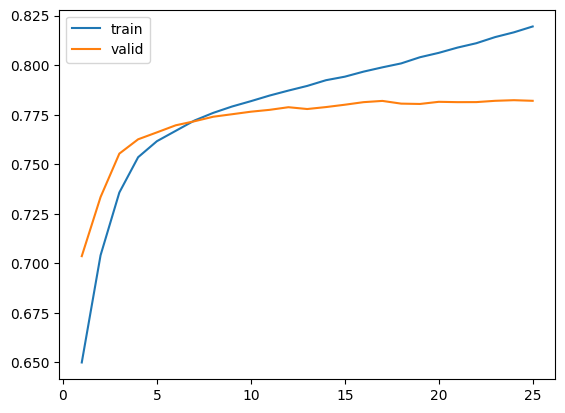

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history.history['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=history.history['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=history.history['val_accuracy'], label='valid')
plt.show()

### 5 – Inferencia

In [91]:
encoder_model = Model(encoder_inputs, encoder_states)

# define inference decoder
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# En cada predicción habrá una sola palabra de entrada al decoder,
# que es la realimentación de la palabra anterior
# por lo que hay que modificar el input shape de la layer de Embedding
decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_single_x, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states)

In [92]:
idx2word = {v: k for k, v in tokenizer_out.word_index.items()}

def chat(question):
    seq = tokenizer_in.texts_to_sequences([clean_text(question)])
    seq = pad_sequences(seq, maxlen=max_len_in)
    states = encoder_model.predict(seq)
    target = np.array([[tokenizer_out.word_index['<sos>']]])
    result = []
    for _ in range(max_len_out):
        out, h, c = decoder_model.predict([target] + states)
        idx = np.argmax(out[0, 0])
        if idx2word.get(idx) == '<eos>':
            break
        result.append(idx2word.get(idx, ''))
        target = np.array([[idx]])
        states = [h, c]
    return ' '.join(result)

Evaluación

In [93]:
print(chat('Hello, how are you today'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
i m fine


In [94]:
print(chat('what is your favorite movie'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
i like to go to the beach


In [95]:
print(chat('how old are you'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
i am doing well how are you


In [96]:
print(chat('what is your job'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
i am a teacher i am a teacher


In [97]:
print(chat('do you like to teach'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
i do not have a lot of time for that


### Conclusiones

Con la configuración inicial utilizada el chatbot repetía la misma respuesta ('i am a vegan') para diferentes entradas, lo que sugería un problema de sobreajuste o colapso del modelo.

En primer lugar, se aumentó MAX_LEN de 30 a 60 para permitir que más pares de preguntas y respuestas, y más largos, fueran incluidos en el conjunto de entrenamiento. Esto aumentó la cantidad de pares QA de 6366 a 12201. El chatbot cambió su respuesta repetitiva a 'i am a teacher', lo que indicaba que el problema de sobreajuste persistía.

Por último, para abordar el sobreajuste y darle al modelo más capacidad para aprender patrones diversos, aumentamos el número de unidades LSTM (n_units) de 128 a 256 y el número de épocas de entrenamiento de 15 a 25.

Después de estos ajustes y el reentrenamiento, el chatbot generó respuestas variadas para diferentes preguntas, lo que indica una mejora significativa en su capacidad de diversificar las salidas, aunque algunas respuestas aún podrían ser refinadas, ya que no son exactamente coherentes respecto a la pregunta formulada. De todas formas, se considera un nivel aceptable para el objetivo buscado.